In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2025.csv
/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2026.csv


In [2]:
df1=pd.read_csv("/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2025.csv")
df2=pd.read_csv("/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2026.csv")

In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116020 entries, 0 to 116019
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   YEAR           116020 non-null  int64  
 1   MONTH_NUM      116020 non-null  int64  
 2   MONTH_MON      116020 non-null  object 
 3   FLT_DATE       116020 non-null  object 
 4   APT_ICAO       116020 non-null  object 
 5   APT_NAME       116020 non-null  object 
 6   STATE_NAME     116020 non-null  object 
 7   FLT_DEP_1      116020 non-null  int64  
 8   FLT_ARR_1      116020 non-null  int64  
 9   FLT_TOT_1      116020 non-null  int64  
 10  FLT_DEP_IFR_2  34128 non-null   float64
 11  FLT_ARR_IFR_2  34128 non-null   float64
 12  FLT_TOT_IFR_2  34128 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 11.5+ MB


In [4]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9751 entries, 0 to 9750
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   YEAR           9751 non-null   int64  
 1   MONTH_NUM      9751 non-null   int64  
 2   MONTH_MON      9751 non-null   object 
 3   FLT_DATE       9751 non-null   object 
 4   APT_ICAO       9751 non-null   object 
 5   APT_NAME       9751 non-null   object 
 6   STATE_NAME     9751 non-null   object 
 7   FLT_DEP_1      9751 non-null   int64  
 8   FLT_ARR_1      9751 non-null   int64  
 9   FLT_TOT_1      9751 non-null   int64  
 10  FLT_DEP_IFR_2  1860 non-null   float64
 11  FLT_ARR_IFR_2  1860 non-null   float64
 12  FLT_TOT_IFR_2  1860 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 990.5+ KB


In [5]:
df=pd.concat([df1, df2], ignore_index=True)
df["FLT_DATE"]=pd.to_datetime(df["FLT_DATE"])
df=df.sort_values("FLT_DATE")
print(df.shape)
print(df["YEAR"].value_counts())

(125771, 13)
YEAR
2025    116020
2026      9751
Name: count, dtype: int64


In [6]:
missing=df.isnull().mean()*100
missing.sort_values(ascending=False)

FLT_ARR_IFR_2    71.386091
FLT_TOT_IFR_2    71.386091
FLT_DEP_IFR_2    71.386091
MONTH_NUM         0.000000
YEAR              0.000000
APT_ICAO          0.000000
FLT_DATE          0.000000
MONTH_MON         0.000000
APT_NAME          0.000000
FLT_ARR_1         0.000000
FLT_DEP_1         0.000000
STATE_NAME        0.000000
FLT_TOT_1         0.000000
dtype: float64

In [7]:
df["MONTH"]=df["FLT_DATE"].dt.month
df["DAY"]=df["FLT_DATE"].dt.day
df["WEEKDAY"]=df["FLT_DATE"].dt.day_name()

df["TRAFFIC_LEVEL"]=pd.qcut(df["FLT_TOT_1"], 3, labels=["Low", "Medium", "High"])

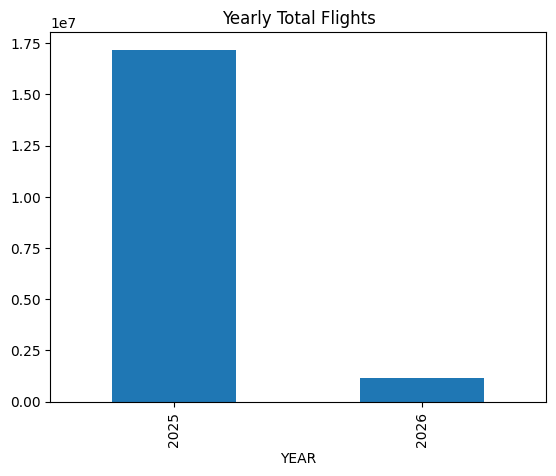

In [8]:
yearly=df.groupby("YEAR")["FLT_TOT_1"].sum()

yearly.plot(kind="bar")
plt.title("Yearly Total Flights")
plt.show()

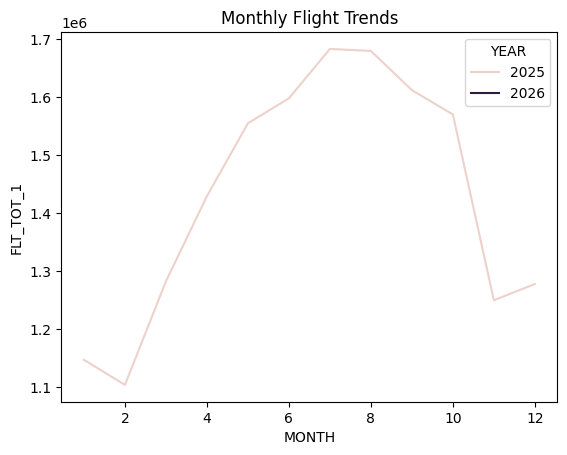

In [9]:
monthly=df.groupby(["YEAR", "MONTH"])["FLT_TOT_1"].sum().reset_index()

sns.lineplot(data=monthly, x="MONTH", y="FLT_TOT_1", hue="YEAR")
plt.title("Monthly Flight Trends")
plt.show()

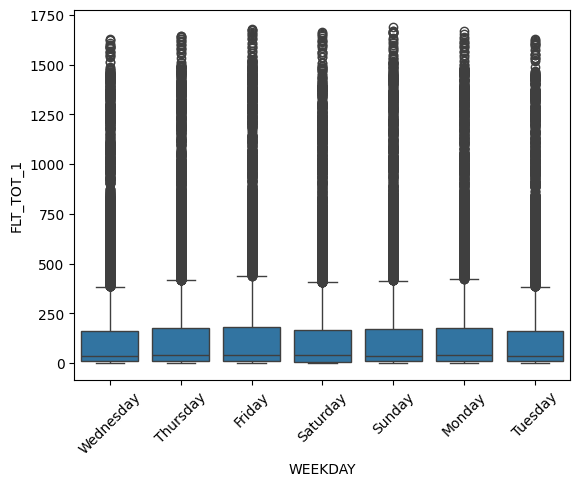

In [10]:
sns.boxplot(x="WEEKDAY", y="FLT_TOT_1", data=df)
plt.xticks(rotation=45)
plt.show()

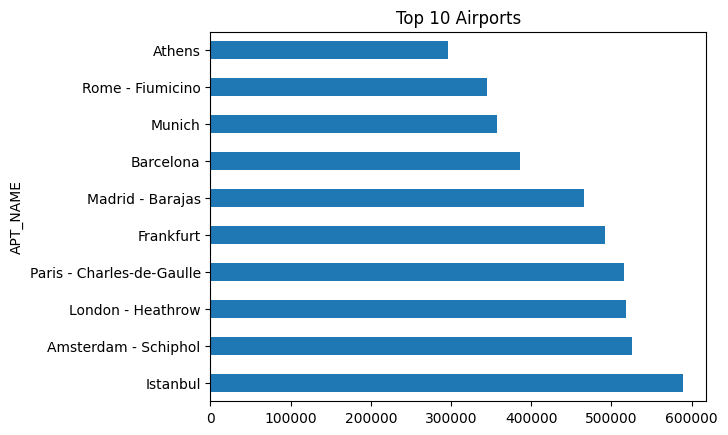

In [11]:
top_airports=df.groupby("APT_NAME")["FLT_TOT_1"].sum()\
                 .sort_values(ascending=False).head(10)
top_airports.plot(kind="barh")
plt.title("Top 10 Airports")
plt.show()

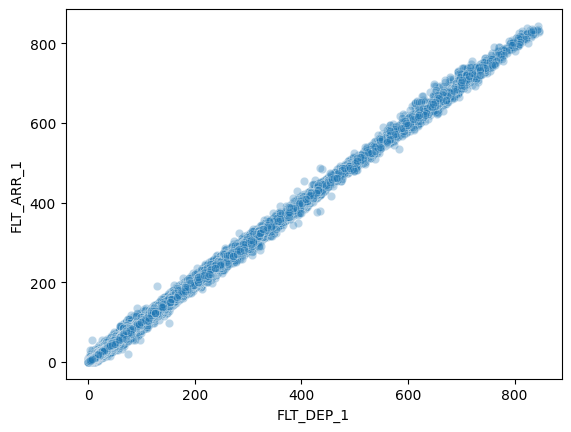

In [12]:
sns.scatterplot(x="FLT_DEP_1", y="FLT_ARR_1", data=df, alpha=0.3)
plt.show()

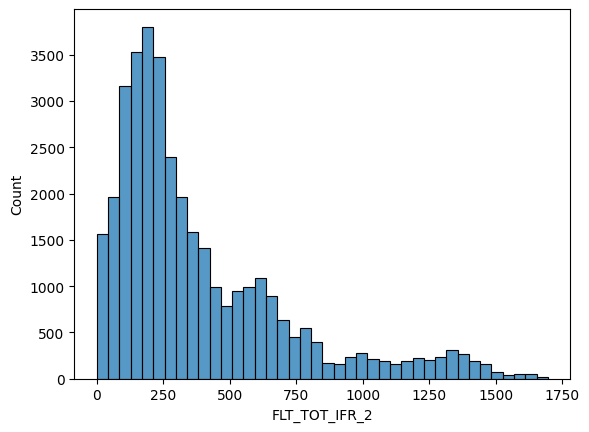

In [13]:
ifr_df=df.dropna(subset=["FLT_TOT_IFR_2"])

sns.histplot(ifr_df["FLT_TOT_IFR_2"], bins=40)
plt.show()

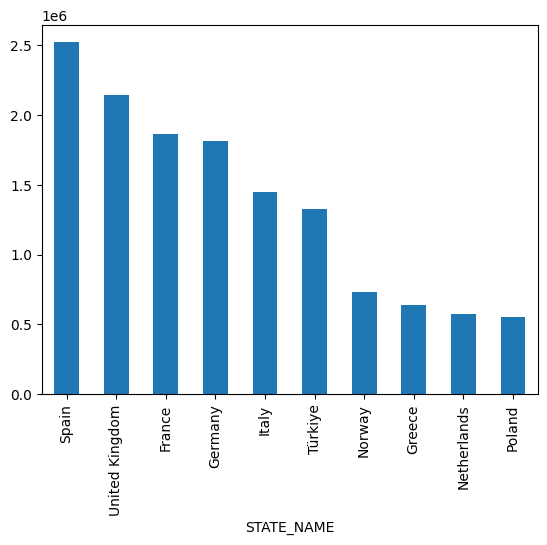

In [14]:
state=df.groupby("STATE_NAME")["FLT_TOT_1"].sum()\
          .sort_values(ascending=False).head(10)

state.plot(kind="bar")
plt.show()

In [15]:
busy_days=df.sort_values("FLT_TOT_1", ascending=False).head(10)
busy_days[["FLT_DATE", "APT_NAME", "FLT_TOT_1"]]

,FLT_DATE,APT_NAME,FLT_TOT_1
63675,2025-07-20,Istanbul,1688
72002,2025-08-15,Istanbul,1680
74244,2025-08-22,Istanbul,1675
67538,2025-08-01,Istanbul,1675
63050,2025-07-18,Istanbul,1675
68168,2025-08-03,Istanbul,1669
79335,2025-09-07,Istanbul,1668
50589,2025-06-09,Istanbul,1666
65292,2025-07-25,Istanbul,1663
70403,2025-08-10,Istanbul,1663


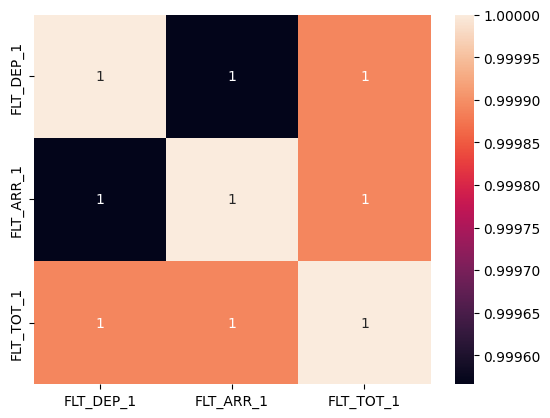

In [16]:
corr=df[["FLT_DEP_1","FLT_ARR_1","FLT_TOT_1"]].corr()

sns.heatmap(corr, annot=True)
plt.show()